## business understanding

This study looked into assessing the heating load and cooling load requirements of buildings (that is, energy efficiency) as a function of building parameters.

We perform energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. We simulate various settings as functions of the afore-mentioned characteristics to obtain 768 building shapes. The dataset comprises 768 samples and 8 features, aiming to predict two real valued responses. It can also be used as a multi-class classification problem if the response is rounded to the nearest integer.


source: Tsanas, A. & Xifara, A. (2012). Energy Efficiency [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C51307.

Data Understanding

- loading
- head and tail( glimpse of how the data looks like)
- shape
- info()
- data types
- descritptive stats (categorical)
- descritptive stats (numerical)
- missing values (data integrity)
- duplicate(data integrity)
- visualization

## loading libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats

## loading dataset

In [23]:
energy_df=pd.read_excel("data/ENB2012_data.xlsx")

## glimplse of the data

In [24]:
energy_df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [25]:
energy_df.tail()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
763,0.64,784.0,343.0,220.5,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.5,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.5,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.5,3.5,4,0.4,5,16.48,16.61
767,0.62,808.5,367.5,220.5,3.5,5,0.4,5,16.64,16.03


In [26]:
rows, columns = energy_df.shape
output = f"This data set has  {rows} RECORDS and  {columns} FEATURES"
print(output)

This data set has  768 RECORDS and  10 FEATURES


In [27]:
energy_df.dtypes

X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
X6      int64
X7    float64
X8      int64
Y1    float64
Y2    float64
dtype: object

insight:
data set has both contionus and discrete data

In [28]:
energy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [29]:
energy_df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='str')

## missing and duplicates

In [30]:
energy_df.isna().sum()

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

insight:
- our dataset has no missing values

In [31]:
energy_df.duplicated().sum()

np.int64(0)

In [32]:
energy_df.isna().sum() *100/len(energy_df) 

X1    0.0
X2    0.0
X3    0.0
X4    0.0
X5    0.0
X6    0.0
X7    0.0
X8    0.0
Y1    0.0
Y2    0.0
dtype: float64

insight:
- our dataset has no duplicate values

## Descriptive stats (numerical and categorical)

| Feature | Description               |
| ------- | ------------------------- |
| X1      | Relative Compactness-continous      |
| X2      | Surface Area- continous              |
| X3      | Wall Area   -continous              |
| X4      | Roof Area -continous                |
| X5      | Overall Height  -continous          |
| X6      | Orientation     - integer          |
| X7      | Glazing Area     -continous         |
| X8      | Glazing Area Distribution- integer |



| Target | Meaning      |
| ------ | -------------|
| Y1     | Heating Load -continous|
| Y2     | Cooling Load -continous|


In [33]:
energy_df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


insights:

**Building Characteristics (X1–X5)**

X1 (Relative Compactness- a metric assessing geometric efficiency by comparing a building's volume-to-envelope-surface-area ratio to a reference shape (like a cube). High relative compactness (minimal surface area per volume) reduces thermal energy demand, lowering both heating and cooling requirements, while increasing energy efficiency, regardless of insulation.)

- Mean is 0.764167 implying moderate compactness
- a maximum of 0.98 which is high implying Higher compactness = better energy efficiency

X2 (Surface Area)

- a Mean of  671
- a sd of  88.086116 implying possiblity of outliers
- a max value of 808.500000 implying Larger buildings result to usually higher energy demand

X3 (Wall Area) & X4 (Roof Area)
Show moderate spread ,design variability
Roof max = 220.5 → capped designs

X5 (Height)
- Only two main values (3.5 and 7)
- Likely low-rise vs high-rise buildings

**Design Factors (X6–X8)**

X6 (Orientation)-(the strategic positioning of a building on a site in relation to environmental factors like the sun, wind, and landscape)
- Ranging from 2 to 5

X7 (Glazing Area)-(the total surface area of transparent or translucent materials,critical for energy efficiency calculations)
-a Mean of  0.23
Ranging from  0 to 0.4
- Some buildings have no windows, others large glass areas

X8 (Glazing Distribution)
- Ranging form 0 to 5
- Different window placement strategies

Y1 (Heating Load)
- a meanof 22.307195
- a low of 6.010000 and a high of 43.100000
- a sd of 10.090204 implying a high variablity

Y2 (Cooling Load)
- a mean of 24.587760
- a sd of 9.513306
- a min 10.900000 of an a high of 48.030000
- iqr of 17.53
- Slightly higher than heating → cooling is more demanding

## visualizations

<Axes: >

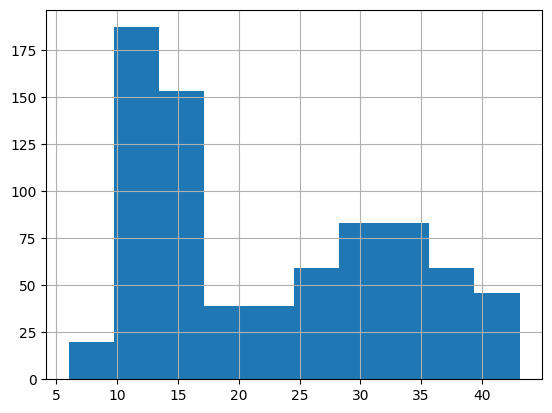

In [ ]:
energy_df['Y1'].hist() ## Heating load

<Axes: xlabel='X5', ylabel='Y1'>

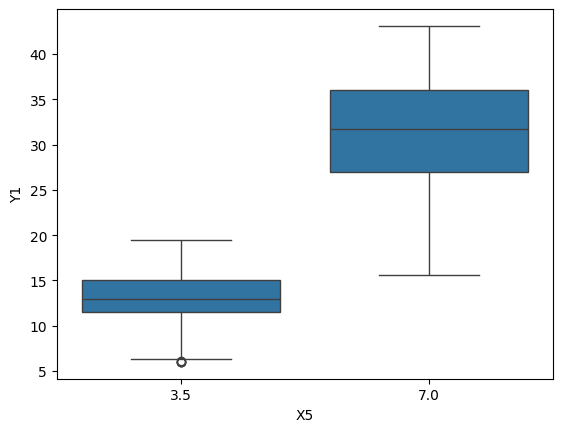

In [42]:

sns.boxplot(x='X5', y='Y1', data=energy_df)

insight:
- we have different types of buildings
- Lower peak → energy-efficient buildings
- Higher peak → energy-demanding buildings

<Axes: >

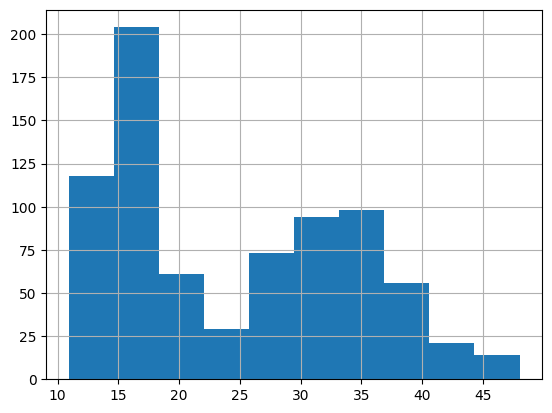

In [41]:
energy_df['Y2'].hist() ## cooling load

<Axes: xlabel='X7', ylabel='Y2'>

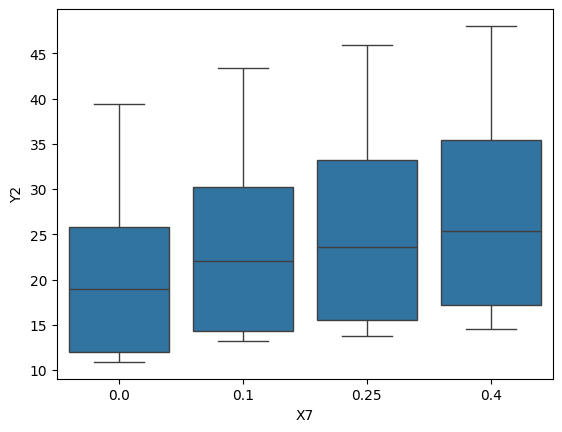

In [43]:

sns.boxplot(x='X7', y='Y2', data=energy_df)

insight:
- Around 10–20 Likely:
More compact buildings
Less glazing (fewer windows)

- Around 30–40 likely:
Larger glazing area 
Less compact designs

**glazing effect**

<Axes: xlabel='X7', ylabel='Y2'>

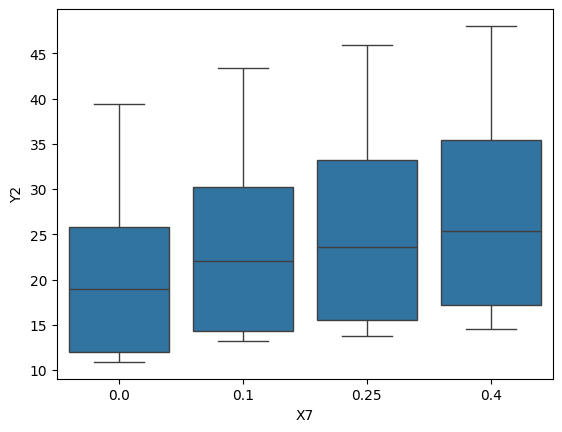

In [44]:

sns.boxplot(x='X7', y='Y2', data=energy_df)

**height effect**

<Axes: xlabel='X5', ylabel='Y2'>

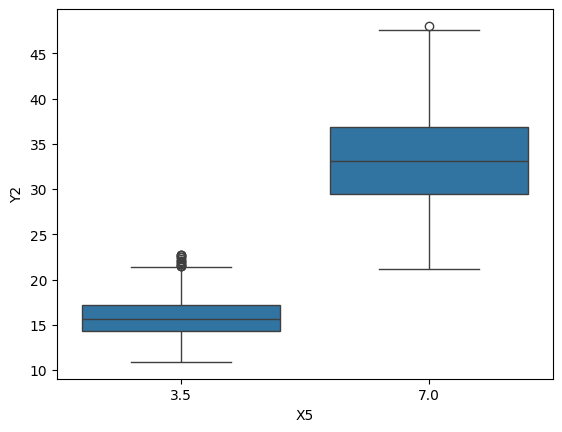

In [45]:
sns.boxplot(x='X5', y='Y2', data=energy_df)

**generally**

The cooling load distribution is bimodal, indicating two distinct building performance groups. This is likely driven by structural features such as glazing area and compactness.

<Axes: xlabel='Y2', ylabel='Count'>

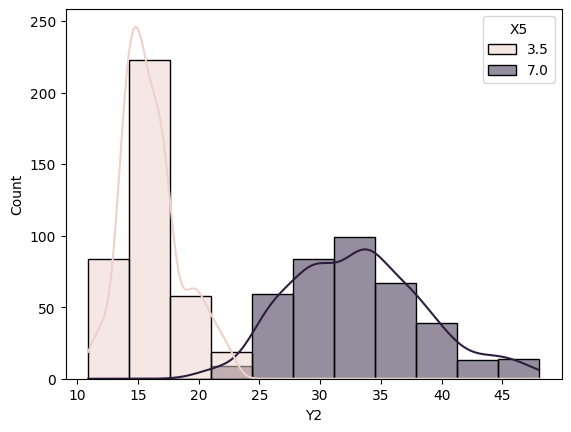

In [46]:
sns.histplot(data=energy_df, x='Y2', hue='X5', kde=True)

insight:
- Height (X5) is a major driver of cooling load
- Tall buildings (X5 = 7.0) Wider spread hence Higher energy demand and a Cooling load of  around 25–45
- Low buildings (X5 = 3.5) Narrow distribution hence More energy efficient and a Cooling load of mostly around 12–20
- Taller buildings trap more heat an dthey require more cooling